# **MÓDULO 34 - Regressão: Conceitos Avançados**

Para essa atividade vocês trabalharão com a mesma base que usamos na aula, para previsão do aluguel.

Durante a aula montamos um modelo de regressão polinomial utilizando a variavel Valor Condominio para prever a variavel valor aluguel. Nessa atividade vocês devem escolher outra váriavel dessa base para realizar a previsão do valor do aluguel.


# 1 - Realize a importação das bibliotecas necessárias, carrega a base de dados e separe em X e Y, selecionando uma das váriaveis para X não sendo a usada durante a aula.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

# Carregando a base de dados
df = pd.read_csv('ALUGUEL_MOD12.csv', sep=';')

# Definindo X (Metragem) e y (Valor_Aluguel)
X = df[['Metragem']] 
y = df['Valor_Aluguel']

# 2 - Faça o procecssamento dos dados utilizando o Polynomial Feature, com degree = 2.

In [11]:
# Criando o transformador polinomial de grau 2
poly_g2 = PolynomialFeatures(degree=2)

# Transformando a variável X para incluir o termo quadrático (X²)
X_poly = poly_g2.fit_transform(X)

# 3 - Separe os dados em treino e teste e realize o treinamento do modelo.

In [12]:
# Dividindo em 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Criando e treinando o modelo de regressão linear nos dados transformados
modelo_grau2 = LinearRegression()
modelo_grau2.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


4 - Faça as previsões para a base de teste e avalie os resultados obtidos, não se esqueça de plotar o gráfico da regressão.

R² Score (Grau 2): 0.5711
Mean Squared Error (Grau 2): 4645995.56


c:\Users\rodri\Dev\ciencia_de_dados_v2\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


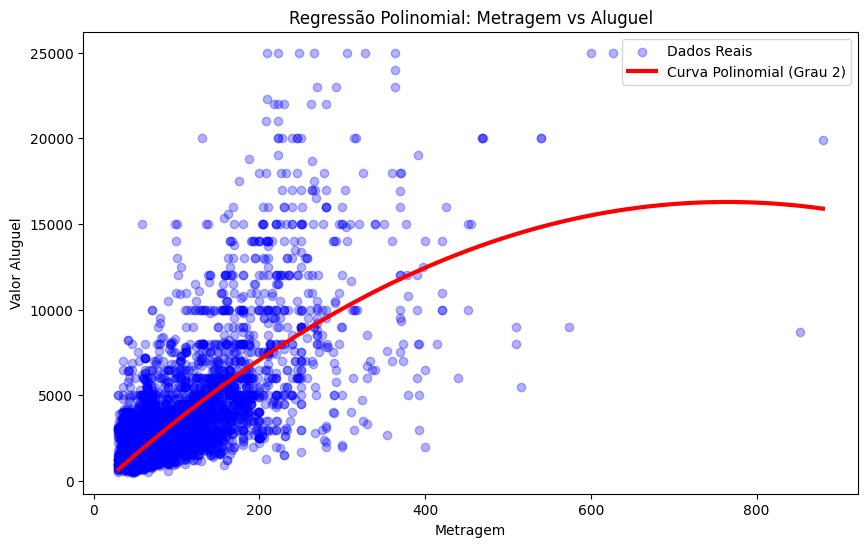

In [13]:
# Fazendo as previsões
y_pred = modelo_grau2.predict(X_test)

# Avaliando
print(f"R² Score (Grau 2): {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error (Grau 2): {mean_squared_error(y_test, y_pred):.2f}")

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.3, label='Dados Reais')

# Linha da curva de regressão
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred = modelo_grau2.predict(poly_g2.transform(X_range))
plt.plot(X_range, y_range_pred, color='red', linewidth=3, label='Curva Polinomial (Grau 2)')

plt.xlabel('Metragem')
plt.ylabel('Valor Aluguel')
plt.title('Regressão Polinomial: Metragem vs Aluguel')
plt.legend()
plt.show()

# 5 - Refaça os passos anteriores, rodando um novo modelo, porém testando agora na fase de processamento o degree = 4. Avalie se o resultado desse novo modelo está superior ao anterior.

R² Score (Grau 4): 0.5585
Mean Squared Error (Grau 4): 4782486.11


c:\Users\rodri\Dev\ciencia_de_dados_v2\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


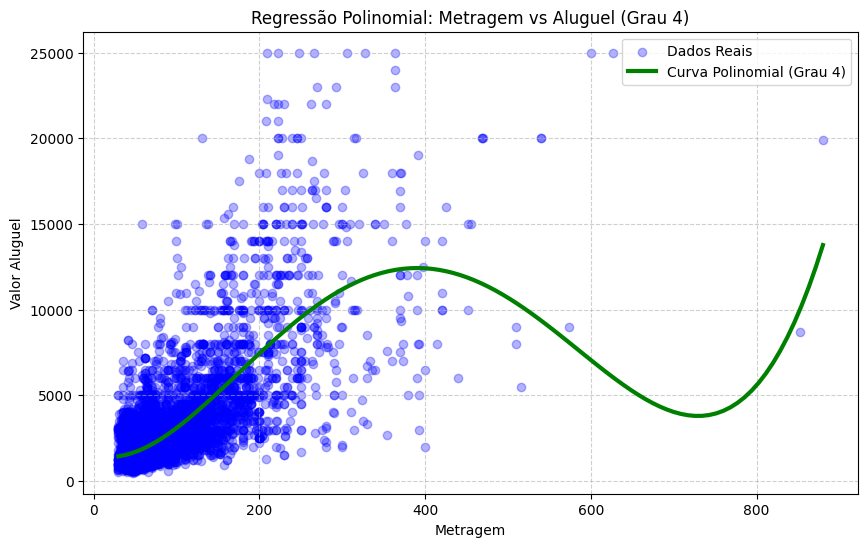

In [ ]:
# Processamento grau 4
poly_g4 = PolynomialFeatures(degree=4)
X_poly4 = poly_g4.fit_transform(X)

# Separação e Treino
X_train4, X_test4, y_train4, y_test4 = train_test_split(X_poly4, y, test_size=0.2, random_state=42)
modelo_grau4 = LinearRegression()
modelo_grau4.fit(X_train4, y_train4)

# Avaliação
y_pred4 = modelo_grau4.predict(X_test4)
print(f"R² Score (Grau 4): {r2_score(y_test4, y_pred4):.4f}")
print(f"Mean Squared Error (Grau 4): {mean_squared_error(y_test4, y_pred4):.2f}")

# Plotagem do Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.3, label='Dados Reais')

# Criando a linha da curva para o Grau 4
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred4 = modelo_grau4.predict(poly_g4.transform(X_range))
plt.plot(X_range, y_range_pred4, color='green', linewidth=3, label='Curva Polinomial (Grau 4)')

plt.xlabel('Metragem')
plt.ylabel('Valor Aluguel')
plt.title('Regressão Polinomial: Metragem vs Aluguel (Grau 4)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Análise dos Resultados**:

Ao rodar os testes, o modelo de Grau 2, tivemos um $R^2$ de 0.5711, enquanto o de Grau 4 caiu para 0.5585. Isso demonstra que aumentar a complexidade do polinômio nem sempre melhora o modelo, podendo torná-lo menos eficiente para prever dados novos.

# 6 - Explique com suas palavras o conceito e a diferença entre Elastic Net, Ridge e Lasso.


Resposta:

A regularização serve para evitar o overfitting, controlando a complexidade do modelo. 
- O **Ridge** (L2) adiciona uma penalidade baseada no quadrado dos coeficientes, forçando-os a serem pequenos mas nunca zero, o que traz estabilidade. 
- O **Lasso** (L1) penaliza o valor absoluto dos coeficientes, o que permite zerar variáveis irrelevantes, funcionando como uma seleção automática de atributos. 
- **Elastic Net** é uma solução híbrida que combina as penalidades L1 e L2, sendo muito útil quando temos múltiplas variáveis correlacionadas entre si.